In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load the dataset
data = load_breast_cancer()
# Convert to a DataFrame to inspect and "clean" (as per EMSI requirements)
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Checking for missing values (Cleaning step)
print(f"Missing values:\n{df.isnull().sum().sum()}")

Missing values:
0


In [3]:
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1).values
y = df['target'].values

# Initialize the scaler
scaler = StandardScaler()

# Standardize features: Mean=0, Variance=1
X_scaled = scaler.fit_transform(X)

In [4]:
import torch
from sklearn.model_selection import train_test_split

# 1. Split: 70% Train, 15% Val, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 2. Check for GPU (device management requirement)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 3. Convert to Tensors and move to Device
X_train_t = torch.tensor(X_train).float().to(device)
y_train_t = torch.tensor(y_train).float().unsqueeze(1).to(device) # unsqueeze adds a dimension for the loss function

X_val_t = torch.tensor(X_val).float().to(device)
y_val_t = torch.tensor(y_val).float().unsqueeze(1).to(device)

X_test_t = torch.tensor(X_test).float().to(device)
y_test_t = torch.tensor(y_test).float().unsqueeze(1).to(device)

Using device: cpu


In [5]:
# Version 1: Simple and linear
input_size = X_train.shape[1] # This will be 30
model_sequential = nn.Sequential(
    nn.Linear(input_size, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1) # Output is 1 because it's binary classification
).to(device)

In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        # Define the layers
        self.layer1 = nn.Linear(input_dim, 16)
        self.layer2 = nn.Linear(16, 8)
        self.output = nn.Linear(8, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Define the flow of data
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)
        return x

# Instantiate the class model
model_custom = MLP(input_size).to(device)

In [7]:
def initialize_weights(model, strategy):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if strategy == 'constant':
                nn.init.constant_(m.weight, 0.05)
                nn.init.constant_(m.bias, 0)
            elif strategy == 'gaussian':
                nn.init.normal_(m.weight, mean=0, std=1.0)
                nn.init.constant_(m.bias, 0)
            elif strategy == 'xavier':
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

In [8]:
def train_model(strategy, epochs=50):
    # Initialize model and move to CPU/GPU
    model = MLP(input_size).to(device)
    initialize_weights(model, strategy)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    loss_history = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        
        loss.backward()
        optimizer.step()
        
        loss_history.append(loss.item())
        
    return loss_history

Training with constant initialization...
Training with gaussian initialization...
Training with xavier initialization...


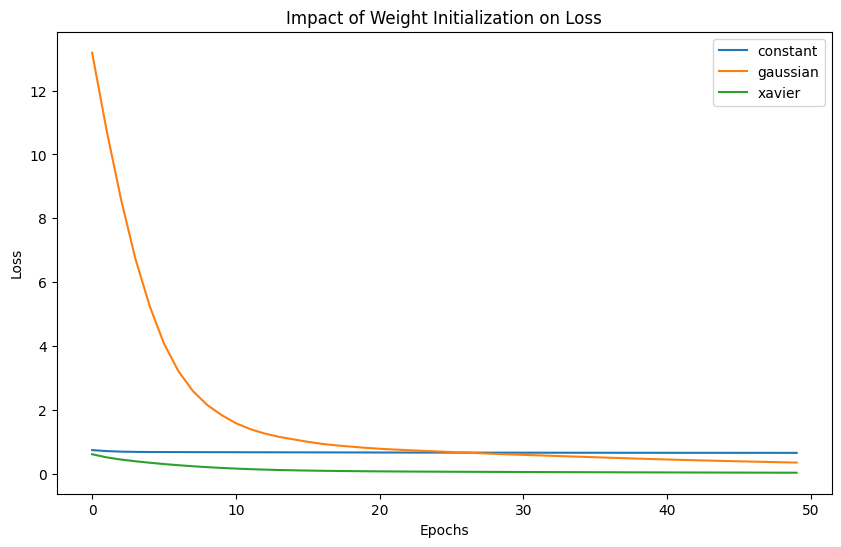

In [9]:
strategies = ['constant', 'gaussian', 'xavier']
results = {}

for s in strategies:
    print(f"Training with {s} initialization...")
    results[s] = train_model(s)

# Plotting the results
plt.figure(figsize=(10, 6))
for s in strategies:
    plt.plot(results[s], label=s)
plt.title('Impact of Weight Initialization on Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [10]:
# 1. Initialize with the winning strategy
initialize_weights(model_custom, 'xavier')

# 2. Re-train for 100 epochs to ensure convergence
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_custom.parameters(), lr=0.005)

for epoch in range(100):
    model_custom.train()
    optimizer.zero_grad()
    outputs = model_custom(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

print("Re-training complete. Now check your Confusion Matrix again!")

Re-training complete. Now check your Confusion Matrix again!


Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        26
         1.0       1.00      1.00      1.00        60

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86



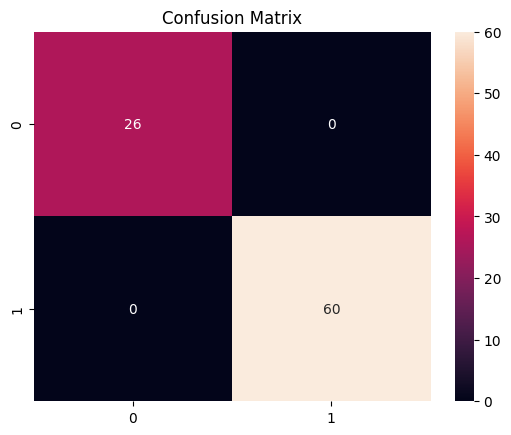

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Use the best model (Xavier)
model_custom.eval() # Set to evaluation mode
with torch.no_grad():
    y_pred_logits = model_custom(X_test_t)
    y_pred_probs = torch.sigmoid(y_pred_logits)
    y_pred = (y_pred_probs > 0.5).float()

# Convert back to CPU/numpy for metrics
y_pred_np = y_pred.cpu().numpy()
y_test_np = y_test_t.cpu().numpy()

print("Classification Report:\n", classification_report(y_test_np, y_pred_np))

# Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred_np)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

In [12]:
import os

# Ensure the data folder exists (just in case)
data_path = '../data'
if not os.path.exists(data_path):
    os.makedirs(data_path)

# Save the DataFrame to your project folder
csv_filename = os.path.join(data_path, 'breast_cancer_data.csv')
df.to_csv(csv_filename, index=False)

print(f"Dataset successfully saved to: {csv_filename}")

Dataset successfully saved to: ../data\breast_cancer_data.csv


In [13]:
# Pick the first sample from the test set
sample = X_test_t[0].unsqueeze(0) 
actual_label = y_test_t[0]

model_custom.eval()
with torch.no_grad():
    prediction_logit = model_custom(sample)
    prediction = (torch.sigmoid(prediction_logit) > 0.5).float()

print(f"Model Prediction: {prediction.item()}")
print(f"Actual Label: {actual_label.item()}")

Model Prediction: 1.0
Actual Label: 1.0


In [14]:
import torch
import torchvision
import torchvision.transforms as transforms

# 1. Define Transformation (Images must be converted to Tensors and Normalized)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Mean and Std for MNIST
])

# 2. Download and Load
train_set = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

print(f"Successfully loaded {len(train_set)} training images!")

Successfully loaded 60000 training images!


In [15]:
import os

# Create the folder if it doesn't exist
model_path = '../models'
if not os.path.exists(model_path):
    os.makedirs(model_path)

# Save the "State Dict" (the weights and biases)
torch.save(model_custom.state_dict(), '../models/best_mlp_model.pth')

print("Success! Your trained MLP is now saved in the models/ folder.")

Success! Your trained MLP is now saved in the models/ folder.
